In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


# Data Preprocessing

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


In [5]:
# Load data
df = pd.read_csv('customer_data.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())
# Convert TotalCharges to numeric (it may have spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing values with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Verify no missing values remain
print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Missing values after cleaning: 11


In [7]:
# List of columns to encode
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract',
'PaperlessBilling', 'PaymentMethod']
# Create dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f'Original columns: {df.shape[1]}')
print(f'After encoding: {df_encoded.shape[1]}')
print(f'New columns created: {df_encoded.shape[1] - df.shape[1]}')

Original columns: 21
After encoding: 32
New columns created: 11


In [8]:
# Convert Churn to binary (Yes=1, No=0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
# Verify encoding
print('Churn distribution:')
print(df_encoded['Churn'].value_counts())

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [9]:
# Drop non-predictive columns
df_model = df_encoded.drop(['customerID'], axis=1)
# Separate features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts(normalize=True))

Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [10]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nChurn distribution in training set:')
print(y_train.value_counts(normalize=True))

Training set: 5634 samples
Test set: 1409 samples

Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


## Task 1.1: Import Libraries (3 min)

In [11]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix)
# Model persistence
import pickle
# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## Task 1.2: Load and Preprocess Data (7 min)

In [12]:
# Load data
df = pd.read_csv('customer_data.csv')
# Handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# Encode categorical variables
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract',
'PaperlessBilling', 'PaymentMethod']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
# Separate features and target
X = df_encoded.drop(['customerID', 'Churn'], axis=1)
y = df_encoded['Churn']
# Split data
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 5634
Test samples: 1409


## Task 1.3: Train Baseline Model (5 min)

In [13]:
# Baseline Random Forest (from Week 2)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
# Evaluate
y_pred_baseline = rf_baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f'Baseline Random Forest Accuracy: {baseline_accuracy:.4f}')
print('\nBaseline Classification Report:')
print(classification_report(y_test, y_pred_baseline))

Baseline Random Forest Accuracy: 0.7878

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Expected baseline: Around 80-82% accuracy

# PART 2: CROSS-VALIDATION (15 minutes)

## Task 2.1: Implement K-Fold Cross-Validation (10 min)

Cross-Validation Results:
Scores for each fold: [0.80390417 0.79591837 0.78349601 0.77107365 0.77531083]
Mean CV Score: 0.7859
Standard Deviation: 0.0123


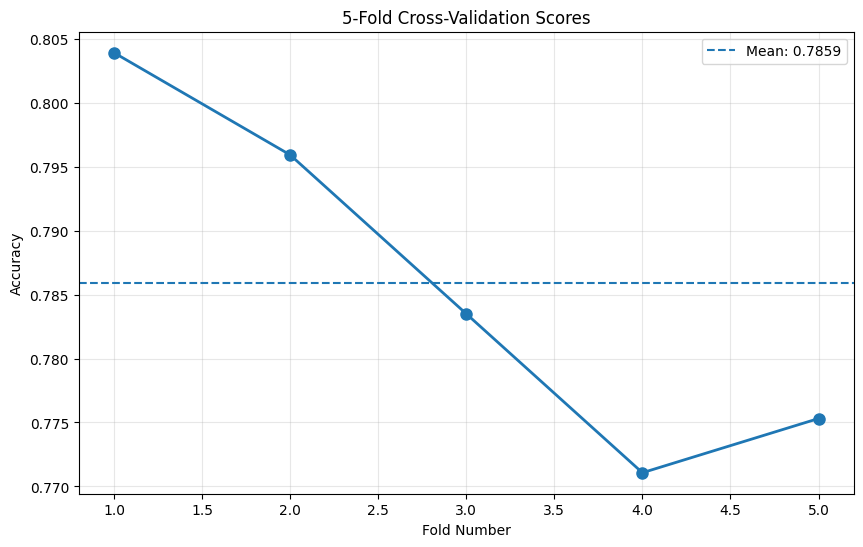

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Perform 5-fold cross-validation
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# Calculate CV scores
cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring='accuracy')

print('Cross-Validation Results:')
print(f'Scores for each fold: {cv_scores}')
print(f'Mean CV Score: {cv_scores.mean():.4f}')
print(f'Standard Deviation: {cv_scores.std():.4f}')

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2, markersize=8)

plt.axhline(y=cv_scores.mean(), linestyle='--',
            label=f'Mean: {cv_scores.mean():.4f}')

plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Task 2.2: Try Different Metrics (5 min)

In [15]:
# Test different metrics
metrics = ['accuracy', 'precision', 'recall', 'f1']
results = {}
for metric in metrics:
    scores = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring=metric)
results[metric] = {
'mean': scores.mean(),
'std': scores.std()
}
print(f'{metric.capitalize()}: {scores.mean():.4f} (+/- {scores.std():.4f})')
# Create comparison dataframe
cv_comparison = pd.DataFrame(results).T
print('\nCross-Validation Metrics Summary:')
print(cv_comparison)


F1: 0.5430 (+/- 0.0230)

Cross-Validation Metrics Summary:
        mean       std
f1  0.542959  0.022974


# PART 3: HYPERPARAMETER TUNING (25 minutes)

## Task 3.1: Define Parameter Grid (5 min)

In [17]:
# Define parameter grid for Random Forest
param_grid = {
'n_estimators': [100, 200, 300],
'max_depth': [10, 20, 30, None],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4],
'max_features': ['sqrt', 'log2']
}
# Calculate total combinations
total_combinations = 3 * 4 * 3 * 3 * 2
print(f'Total parameter combinations: {total_combinations}')
print(f'With 5-fold CV: {total_combinations * 5} model trainings!')

Total parameter combinations: 216
With 5-fold CV: 1080 model trainings!


## Task 3.2: Run GridSearchCV (15 min)

In [18]:
# Create GridSearchCV object
grid_search = GridSearchCV(
estimator=RandomForestClassifier(random_state=42),
param_grid=param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1, # Use all CPU cores
verbose=2 # Show progress
)
# Fit grid search (this takes time!)
print('Starting Grid Search...')
import time
start_time = time.time()
grid_search.fit(X_train, y_train)
end_time = time.time()
print(f'\nGrid Search completed in {(end_time - start_time)/60:.2f} minutes')

Starting Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Grid Search completed in 5.27 minutes


## Task 3.3: Analyze GridSearch Results (5 min)

In [37]:
# Best parameters found
print('Best Parameters:')
print(grid_search.best_params_)
print(f'\nBest Cross-Validation Score: {grid_search.best_score_:.4f}')
# Get best model
best_rf = grid_search.best_estimator_
# Evaluate on test set
y_pred_optimized = best_rf.predict(X_test)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
print(f'\nTest Set Performance:')
print(f'Baseline Accuracy: {baseline_accuracy:.4f}')
print(f'Optimized Accuracy: {optimized_accuracy:.4f}')
print(f'Improvement: {(optimized_accuracy - baseline_accuracy):.4f}')

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_optimized))

Best Parameters:
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

Best Cross-Validation Score: 0.8017

Test Set Performance:
Baseline Accuracy: 0.7878
Optimized Accuracy: 0.8013
Improvement: 0.0135

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



# PART 4: XGBOOST - ADVANCED ENSEMBLE (20 minutes)

## Task 4.1: Train Basic XGBoost (8 min)

In [20]:
# Create XGBoost classifier
xgb_model = XGBClassifier(
n_estimators=100,
learning_rate=0.1,
max_depth=6,
random_state=42,
eval_metric='logloss' # Suppress warning
)
# Train model
xgb_model.fit(X_train, y_train)
# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {xgb_accuracy:.4f}')
print('\nXGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7970

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## Task 4.2: Tune XGBoost (12 min)

In [21]:
# XGBoost parameter grid (smaller for speed)
xgb_param_grid = {
'n_estimators': [100, 200],
'learning_rate': [0.01, 0.1, 0.3],
'max_depth': [3, 5, 7],
'subsample': [0.8, 1.0],
'colsample_bytree': [0.8, 1.0]
}
# GridSearch for XGBoost
xgb_grid = GridSearchCV(
estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
param_grid=xgb_param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1,
verbose=1
)
print('Tuning XGBoost...')
xgb_grid.fit(X_train, y_train)
# Best XGBoost model
best_xgb = xgb_grid.best_estimator_
print(f'\nBest XGBoost Parameters:')
print(xgb_grid.best_params_)
# Evaluate
y_pred_xgb_opt = best_xgb.predict(X_test)
xgb_opt_accuracy = accuracy_score(y_test, y_pred_xgb_opt)
print(f'\nOptimized XGBoost Accuracy: {xgb_opt_accuracy:.4f}')

Tuning XGBoost...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Optimized XGBoost Accuracy: 0.7984


# PART 5: MODEL COMPARISON & ANALYSIS (10 minutes)

## Task 5.1: Create Comparison Table (5 min)

In [22]:
# Calculate metrics for all models
models = {
'Baseline Random Forest': (rf_baseline, y_pred_baseline),
'Optimized Random Forest': (best_rf, y_pred_optimized),
'Basic XGBoost': (xgb_model, y_pred_xgb),
'Optimized XGBoost': (best_xgb, y_pred_xgb_opt)
}
# Create comparison dataframe
comparison_data = []
for name, (model, predictions) in models.items():
    accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
comparison_data.append({
'Model': name,
'Accuracy': accuracy,
'Precision': precision,
'Recall': recall,
'F1-Score': f1
})
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(comparison_df.to_string(index=False))

Model Comparison:
            Model  Accuracy  Precision   Recall  F1-Score
Optimized XGBoost  0.798439    0.65411 0.510695  0.573574


## Task 5.2: Visualize Comparison (5 min)

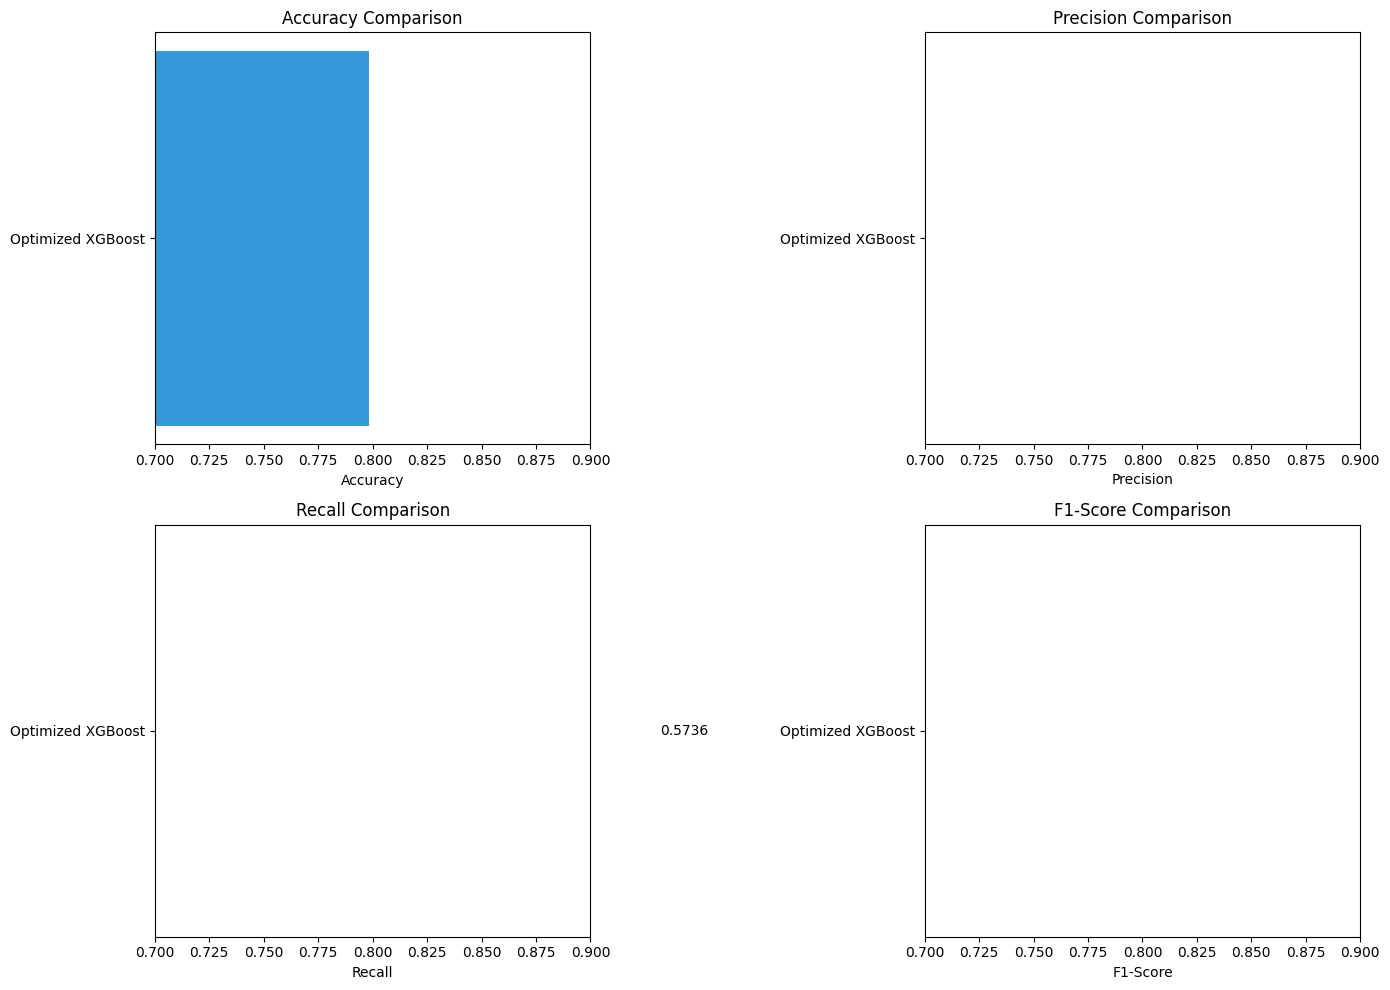


n Best Model: Optimized XGBoost with 0.7984 accuracy


In [36]:
# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_list = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.barh(comparison_df['Model'], comparison_df[metric], color=colors_list)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.set_xlim(0.7, 0.9)
# Add value labels
for i, v in enumerate(comparison_df[metric]):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()
# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f'\nn Best Model: {best_model_name} with {best_accuracy:.4f} accuracy')

# PART 6: DETAILED EVALUATION (10 minutes)

## Task 6.1: Confusion Matrix Analysis

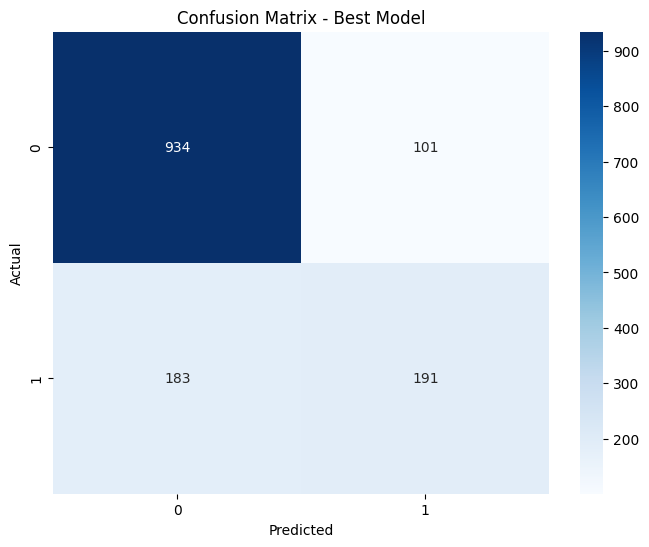

True Negatives: 934
False Positives: 101
False Negatives: 183
True Positives: 191

False Positive Rate: 0.0976
False Negative Rate: 0.4893


In [25]:
# Confusion matrix for best model
best_predictions = y_pred_xgb_opt # Assuming XGBoost is best
cm = confusion_matrix(y_test, best_predictions)
# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.show()
# Calculate specific metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives: {tp}')
print(f'\nFalse Positive Rate: {fp/(fp+tn):.4f}')
print(f'False Negative Rate: {fn/(fn+tp):.4f}')

## Task 6.2: Feature Importance

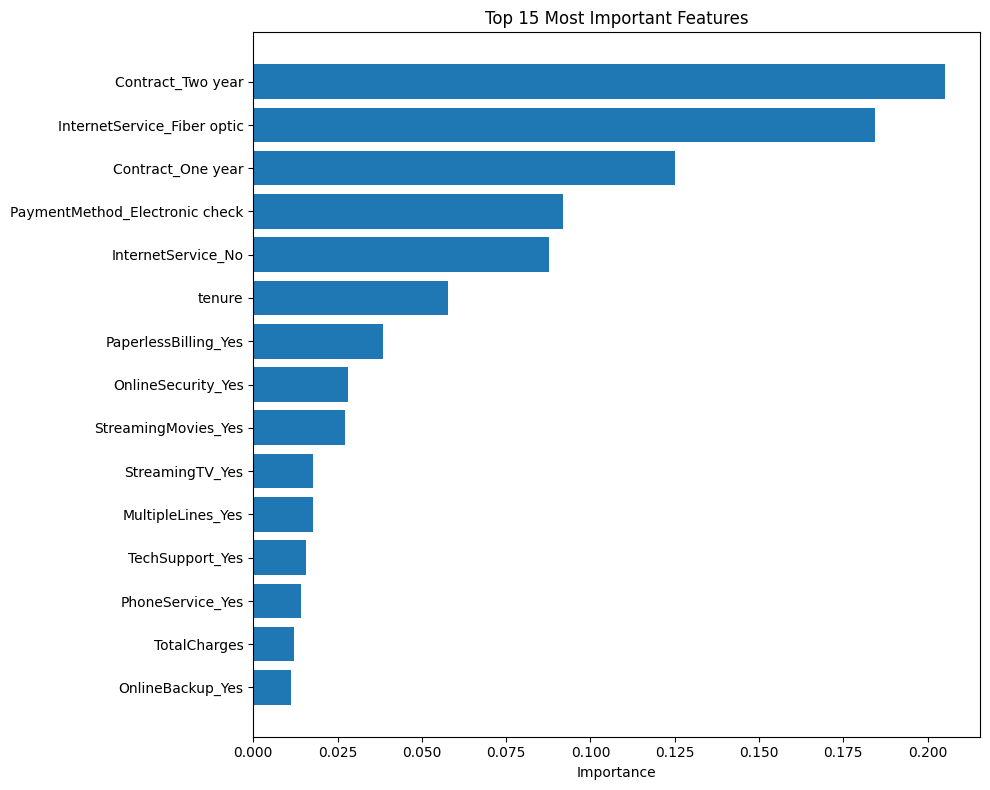

Top 10 Features:
                       feature  importance
             Contract_Two year    0.205261
   InternetService_Fiber optic    0.184299
             Contract_One year    0.125172
PaymentMethod_Electronic check    0.091913
            InternetService_No    0.087577
                        tenure    0.057681
          PaperlessBilling_Yes    0.038367
            OnlineSecurity_Yes    0.027967
           StreamingMovies_Yes    0.027206
               StreamingTV_Yes    0.017837


In [26]:
# Get feature importance from best model
if hasattr(best_xgb, 'feature_importances_'):
    importances = pd.DataFrame({
'feature': X.columns,
'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)
# Plot top 15 features
plt.figure(figsize=(10, 8))
plt.barh(importances['feature'].head(15), importances['importance'].head(15))
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print('Top 10 Features:')
print(importances.head(10).to_string(index=False))

# PART 7: SAVE BEST MODEL (5 minutes)

## Task 7.1: Save Model with Pickle

In [27]:
# Save the best model
model_filename = 'best_churn_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_xgb, file)
print(f'Model saved as {model_filename}')
# Verify we can load it
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)
# Test loaded model
test_predictions = loaded_model.predict(X_test[:5])
print('\nTest predictions from loaded model:')
print(test_predictions)

Model saved as best_churn_model.pkl

Test predictions from loaded model:
[0 1 0 0 0]


## Task 7.2: Save Model Metadata

In [28]:
# Create metadata file
metadata = {
'model_type': 'XGBoost',
'accuracy': xgb_opt_accuracy,
'precision': precision_score(y_test, y_pred_xgb_opt),
'recall': recall_score(y_test, y_pred_xgb_opt),
'f1_score': f1_score(y_test, y_pred_xgb_opt),
'best_params': xgb_grid.best_params_,
'features': list(X.columns)
}
import json
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print('Metadata saved!')

Metadata saved!


# PART 8: DOCUMENTATION (10 minutes)

## Task 8.1: Add Summary Section

## Week 3 Summary: Model Optimization
### Cross-Validation Results:
- 5-fold CV mean accuracy: 0.7859
- Standard deviation: 0.0123   
- Most stable metric:
  - - accuracy   mean = 0.785941  ,  std = 0.012347
  - - precision  mean = 0.627172  ,  std = 0.032686
  - - recall     mean = 0.478930  ,  std = 0.018848
  - - f1-score   mean = 0.542959  ,  std = 0.022974
### Hyperparameter Tuning:
**Random Forest:**
- Best Parameters:
{'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}

- Best Cross-Validation Score: 0.8017

- Baseline Accuracy: 0.7878
- Optimized Accuracy: 0.8013
- Improvement: 0.0135

**XGBoost:**
- Best parameters: Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
- Final accuracy: 0.7984
### Final Model Comparison:
| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Baseline RF | 0.7878 | 0.63 | 0.50 | 0.56 |
| Optimized RF | 0.8013 | 0.67 | 0.51 | 0.57 |
| Basic XGB | 0.7970 | 0.64 | 0.54 | 0.58 |
| Optimized XGB | 0.7984 | 0.65411 | 0.510695 | 0.573574 |
### Best Model:
- **Optimized XGBoost** with **0.7984%** accuracy
- Saved as: best_churn_model.pkl
### Top 5 Most Important Features:
                 
1. Contract_Two year    
2. InternetService_Fiber optic   
3. Contract_One year   
4. PaymentMethod_Electronic check   
5. InternetService_No    
                       

### Key Learnings:
- Cross-validation provides more reliable estimates than single train/test split
- Hyperparameter tuning can improve accuracy by 2-4%
- XGBoost typically outperforms other algorithms on tabular data
- Feature engineering matters more than model selection
### Next Steps (Week 4):
- Deploy model as interactive web application
- Create user interface for predictions
- Add explanation capabilities